# AI-READI Dataset — Surveys, Clinical Measurements & EDA Verification

**Purpose**: This notebook does three things:
1. **Survey & questionnaire profiling** — explores the OMOP observation table (completely absent from NB02)
2. **Clinical measurement profiling** — vitals, labs, and ophthalmology from the measurement table
3. **EDA verification** — resolves specific anomalies flagged in NB02 (sleep data, small-sample clustering, site imbalance, QTc finding)

**Table of Contents**
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Observation Table Structure & Parsing](#2-observation-table-structure--parsing)
3. [CES-D-10 Depression Screening](#3-ces-d-10-depression-screening)
4. [PAID-5 Diabetes Distress](#4-paid-5-diabetes-distress)
5. [Diet Survey & Diabetes Self-Management](#5-diet-survey--diabetes-self-management)
6. [Medical History & Family History](#6-medical-history--family-history)
7. [Survey Completeness Summary](#7-survey-completeness-summary)
8. [Clinical Measurements — Vitals](#8-clinical-measurements--vitals)
9. [Clinical Measurements — Lab Values](#9-clinical-measurements--lab-values)
10. [EDA Verification — Sleep Data Anomaly](#10-eda-verification--sleep-data-anomaly)
11. [EDA Verification — Clustering, QTc & Site Imbalance](#11-eda-verification--clustering-qtc--site-imbalance)
12. [Key Findings & Next Steps](#12-key-findings--next-steps)

---

> **⚠️ Sample Size Caveat (read once, applies everywhere)**  
> The observation sample covers **8 patients**; the measurement sample covers **21 patients**.  
> All survey/measurement profiling in this notebook is **structural** — documenting what data exists and how it is organized.  
> No population-level conclusions should be drawn from these sections.  
> Statistical findings require the full dataset (~2,280 participants).

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

# Load all data files
data_dir = Path('../data/samples')
manifest_dir = data_dir / 'manifests'

obs_df   = pd.read_csv(data_dir / 'observation_sample.csv')
meas_df  = pd.read_csv(data_dir / 'measurement_sample.csv')
eda_df   = pd.read_csv(data_dir / 'eda_merged_dataset.csv')
activity = pd.read_csv(manifest_dir / 'manifest_wearable_activity_monitor.tsv', sep='\t')

print('Data loaded:')
print(f'  Observation sample : {len(obs_df):>5} rows | {obs_df["person_id"].nunique()} unique patients')
print(f'  Measurement sample : {len(meas_df):>5} rows | {meas_df["person_id"].nunique()} unique patients')
print(f'  EDA merged dataset : {len(eda_df):>5} rows | {eda_df["person_id"].nunique()} unique patients')
print(f'  Activity manifest  : {len(activity):>5} rows | {activity["person_id"].nunique()} unique patients')

Data loaded:
  Observation sample :  1000 rows | 8 unique patients
  Measurement sample :  1000 rows | 21 unique patients
  EDA merged dataset :    52 rows | 52 unique patients
  Activity manifest  :  2184 rows | 2184 unique patients


## 2. Observation Table Structure & Parsing

The observation table uses **OMOP CDM long format**: one row per clinical observation per patient.  
The `observation_source_value` field encodes the item as `"item_key, Description text"`.  
We parse the item key and classify rows into categories to understand what is actually in the sample.

In [2]:
# Parse item key from observation_source_value
obs_df['item_key'] = (
    obs_df['observation_source_value']
    .str.strip('"')
    .str.split(',', n=1)
    .str[0]
    .str.strip()
)

# Extract prefix (letters before first digit or underscore)
obs_df['item_prefix'] = obs_df['item_key'].str.extract(r'^([a-zA-Z]+)', expand=False).str.lower()

# Classify by category
retinal_prefixes = {'rtci', 'rtei', 'rtfl', 'rtma', 'rtop', 'rtsm', 'rtso', 'rttr'}
survey_prefixes  = {'ces', 'paid', 'diet', 'dml', 'mh', 'fh', 'su', 'via', 'cm', 'px',
                    'dri', 'pa', 'cl', 'faq', 'mss', 'moca', 'cage', 'prec', 'scr', 'rec'}

def classify_prefix(p):
    if p in retinal_prefixes:
        return 'Retinal imaging flags'
    elif p in survey_prefixes:
        return 'Survey / questionnaire'
    else:
        return 'Admin / timestamp'

obs_df['category'] = obs_df['item_prefix'].apply(classify_prefix)

# Count by category
cat_counts = obs_df['category'].value_counts()
print('Observation rows by category:')
for cat, n in cat_counts.items():
    print(f'  {cat:<30}: {n:>4} rows ({n/len(obs_df)*100:.1f}%)')

print(f'\nTotal unique item keys: {obs_df["item_key"].nunique()}')

Observation rows by category:
  Admin / timestamp             :  703 rows (70.3%)
  Survey / questionnaire        :  165 rows (16.5%)
  Retinal imaging flags         :  132 rows (13.2%)

Total unique item keys: 326


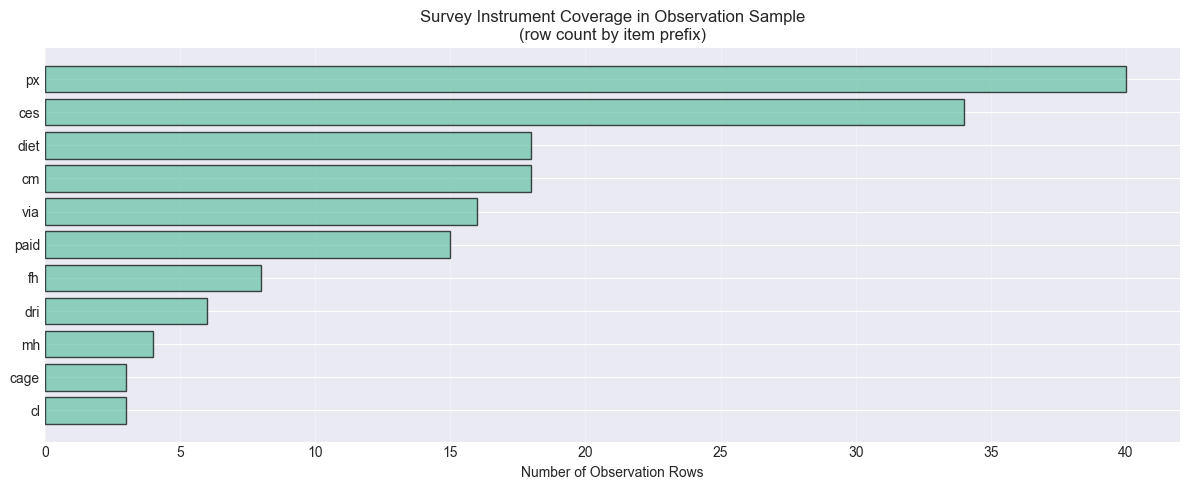


Survey instruments present (by prefix):
  ces   : CES-D-10 (depression screening) — 34 rows
  paid  : PAID-5 (diabetes distress) — 15 rows
  diet  : Diet survey — 18 rows
  dml   : Diabetes self-management — 0 rows
  mh    : Medical history — 4 rows
  fh    : Family history of diabetes — 8 rows
  via   : Visual impairment self-report — 16 rows
  su    : Substance use — 0 rows
  cm    : OTC medications — 18 rows
  px    : PhenX SDOH measures — 40 rows
  pa    : Physical activity assessment — 0 rows
  cl    : Clinical / marital status — 3 rows


In [3]:
# Show survey items by instrument prefix
survey_obs = obs_df[obs_df['category'] == 'Survey / questionnaire'].copy()

prefix_counts = survey_obs['item_prefix'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(prefix_counts.index[::-1], prefix_counts.values[::-1], edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Observation Rows')
ax.set_title('Survey Instrument Coverage in Observation Sample\n(row count by item prefix)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nSurvey instruments present (by prefix):')
instrument_names = {
    'ces': 'CES-D-10 (depression screening)',
    'paid': 'PAID-5 (diabetes distress)',
    'diet': 'Diet survey',
    'dml': 'Diabetes self-management',
    'mh': 'Medical history',
    'fh': 'Family history of diabetes',
    'via': 'Visual impairment self-report',
    'su': 'Substance use',
    'cm': 'OTC medications',
    'px': 'PhenX SDOH measures',
    'pa': 'Physical activity assessment',
    'cl': 'Clinical / marital status',
}
for prefix, name in instrument_names.items():
    n = prefix_counts.get(prefix, 0)
    print(f'  {prefix:<6}: {name} — {n} rows')

## 3. CES-D-10 Depression Screening

The **CES-D-10** is a 10-item validated scale measuring depressive symptoms over the past week.  
Each item is scored 0–3. Total score range: 0–30. **Cutoff ≥ 10 indicates probable depression.**  
Items 5 and 8 are reverse-coded (higher answer = fewer symptoms) — stored pre-reversed in OMOP.

In [4]:
cesd_item_keys = [f'ces{i}' for i in range(1, 11)] + ['cestl']

cesd_long = obs_df[
    obs_df['item_key'].isin(cesd_item_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_with_cesd = cesd_long['person_id'].nunique()
print(f'Patients with CES-D data: {n_with_cesd} / {obs_df["person_id"].nunique()}')

if n_with_cesd == 0:
    print('No CES-D data in this sample.')
else:
    cesd_wide = cesd_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )
    # Reorder columns
    ordered_cols = [c for c in cesd_item_keys if c in cesd_wide.columns]
    cesd_wide = cesd_wide[ordered_cols]

    print(f'\nCES-D item completeness:')
    print(cesd_wide.notna().sum().to_string())

    if 'cestl' in cesd_wide.columns:
        total = cesd_wide['cestl'].dropna()
        print(f'\nTotal score (cestl): mean={total.mean():.1f}, median={total.median():.1f}, range=[{total.min():.0f}, {total.max():.0f}]')
        print(f'Patients at/above cutoff (≥10): {(total >= 10).sum()} / {len(total)}')

    display(cesd_wide)

Patients with CES-D data: 6 / 8

CES-D item completeness:
item_key
ces1     3
ces2     3
ces3     3
ces4     3
ces5     3
ces6     4
ces7     3
ces8     4
ces9     5
ces10    3
cestl    3

Total score (cestl): mean=2.0, median=2.0, range=[0, 4]
Patients at/above cutoff (≥10): 0 / 3


item_key,ces1,ces2,ces3,ces4,ces5,ces6,ces7,ces8,ces9,ces10,cestl
person_id,,,,,,,,,,,
7017,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
7018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN
7029,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0
7072,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7117,0.0,0.0,0.0,0.0,1.0,1.0,2.0,0.0,0.0,0.0,4.0
7124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


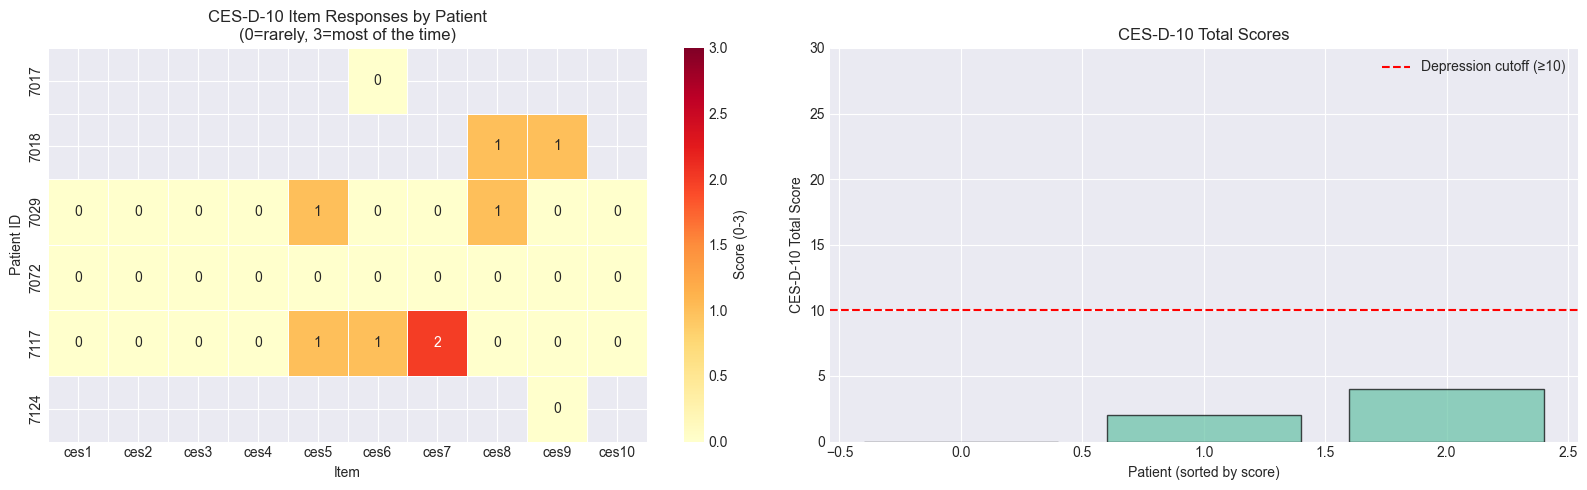

In [5]:
if n_with_cesd > 0 and len(cesd_wide) > 0:
    item_cols = [c for c in cesd_wide.columns if c != 'cestl']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Heatmap of item responses
    if len(item_cols) > 0 and cesd_wide[item_cols].notna().any().any():
        sns.heatmap(
            cesd_wide[item_cols].astype(float),
            ax=axes[0], annot=True, fmt='.0f', cmap='YlOrRd',
            vmin=0, vmax=3, cbar_kws={'label': 'Score (0-3)'},
            linewidths=0.5
        )
        axes[0].set_title('CES-D-10 Item Responses by Patient\n(0=rarely, 3=most of the time)')
        axes[0].set_xlabel('Item')
        axes[0].set_ylabel('Patient ID')

    # Total score distribution
    if 'cestl' in cesd_wide.columns:
        total = cesd_wide['cestl'].dropna()
        axes[1].bar(range(len(total)), sorted(total.values), edgecolor='black', alpha=0.7)
        axes[1].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Depression cutoff (≥10)')
        axes[1].set_xlabel('Patient (sorted by score)')
        axes[1].set_ylabel('CES-D-10 Total Score')
        axes[1].set_title('CES-D-10 Total Scores')
        axes[1].set_ylim(0, 30)
        axes[1].legend()

    plt.tight_layout()
    plt.show()

## 4. PAID-5 Diabetes Distress

The **PAID-5** (Problem Areas in Diabetes, 5-item version) measures emotional distress related to diabetes management.  
Each item is scored 0–4. Total score range: 0–100 (after ×5 scaling). **Cutoff ≥ 40 indicates high distress.**  
> Note: PAID-5 is only administered to participants with a diabetes diagnosis — not healthy controls.

Patients with PAID-5 data: 4 / 8
(Expected: only diabetes patients, not healthy controls)

PAID-5 total score: mean=2.8, range=[0, 10]
High distress (≥40): 0 / 4


item_key,paid_scrd,paid_dpr,paid_wr,paid_eng,paid_cml,paidscore
person_id,,,,,,
7029,0.0,0.0,0.0,0.0,0.0,0.0
7072,4.0,3.0,3.0,0.0,0.0,10.0
7117,0.0,0.0,1.0,0.0,0.0,1.0
7687,NaN,NaN,NaN,NaN,NaN,0.0


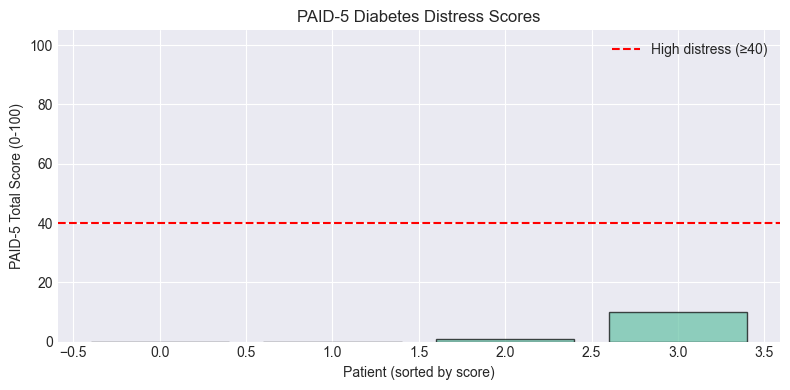

In [6]:
paid_item_keys = ['paid_scrd', 'paid_dpr', 'paid_wr', 'paid_eng', 'paid_cml', 'paidscore']

paid_long = obs_df[
    obs_df['item_key'].isin(paid_item_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_with_paid = paid_long['person_id'].nunique()
print(f'Patients with PAID-5 data: {n_with_paid} / {obs_df["person_id"].nunique()}')
print('(Expected: only diabetes patients, not healthy controls)')

if n_with_paid > 0:
    paid_wide = paid_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )
    ordered_paid = [c for c in paid_item_keys if c in paid_wide.columns]
    paid_wide = paid_wide[ordered_paid]

    if 'paidscore' in paid_wide.columns:
        total = paid_wide['paidscore'].dropna()
        print(f'\nPAID-5 total score: mean={total.mean():.1f}, range=[{total.min():.0f}, {total.max():.0f}]')
        print(f'High distress (≥40): {(total >= 40).sum()} / {len(total)}')

    display(paid_wide)

    if 'paidscore' in paid_wide.columns and len(paid_wide['paidscore'].dropna()) > 0:
        fig, ax = plt.subplots(figsize=(8, 4))
        total = paid_wide['paidscore'].dropna()
        ax.bar(range(len(total)), sorted(total.values), edgecolor='black', alpha=0.7)
        ax.axhline(40, color='red', linestyle='--', linewidth=1.5, label='High distress (≥40)')
        ax.set_xlabel('Patient (sorted by score)')
        ax.set_ylabel('PAID-5 Total Score (0-100)')
        ax.set_title('PAID-5 Diabetes Distress Scores')
        ax.set_ylim(0, 105)
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('No PAID-5 data in this observation sample.')

## 5. Diet Survey & Diabetes Self-Management

**Diet survey** (`diet1`–`diet9`, `dietscore`): Assesses dietary quality and habits.  
**Diabetes self-management** (`dml*`): Assesses self-care behaviors across domains — physical activity, diet adherence, education, foot care, medication management.

In [7]:
# --- Diet Survey ---
diet_item_keys = [f'diet{i}' for i in range(1, 10)] + ['dietscore']

diet_long = obs_df[
    obs_df['item_key'].isin(diet_item_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_diet = diet_long['person_id'].nunique()
print(f'Diet survey — patients with data: {n_diet}')

if n_diet > 0:
    diet_wide = diet_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )
    if 'dietscore' in diet_wide.columns:
        ds = diet_wide['dietscore'].dropna()
        print(f'  Diet score: mean={ds.mean():.1f}, range=[{ds.min():.0f}, {ds.max():.0f}]')
    display(diet_wide)

# --- Diabetes Self-Management ---
dml_all = obs_df[obs_df['item_key'].str.startswith('dml')][['person_id', 'item_key', 'value_as_number']].copy()
n_dml = dml_all['person_id'].nunique()
print(f'\nDiabetes self-management — patients with data: {n_dml}')

dml_domains = {
    'Physical activity': ['dmlact', 'dmlvex', 'dmlhex'],
    'Diet adherence'   : ['dmlsugar', 'dmlgrain', 'dmlpor', 'dmlfrveg'],
    'Education'        : ['dmledu'],
    'Foot care'        : ['dmlfeet'],
    'Medical mgmt'     : ['dmlmd'],
}

if n_dml > 0:
    dml_wide = dml_all.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )
    print('\nDiabetes self-management domain means (this sample):')
    for domain, keys in dml_domains.items():
        present = [k for k in keys if k in dml_wide.columns]
        if present:
            means = dml_wide[present].mean(axis=1).mean()
            print(f'  {domain:<22}: mean score = {means:.2f}')
    display(dml_wide)

Diet survey — patients with data: 2
  Diet score: mean=7.0, range=[7, 7]


item_key,diet1,diet2,diet3,diet4,diet5,diet6,diet7,diet8,diet9,dietscore
person_id,,,,,,,,,,
7072,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
7117,2.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,7.0



Diabetes self-management — patients with data: 4

Diabetes self-management domain means (this sample):
  Physical activity     : mean score = 6.67
  Diet adherence        : mean score = 5.00
  Education             : mean score = 0.00
  Foot care             : mean score = 3.33
  Medical mgmt          : mean score = 8.33


item_key,dmlact,dmledu,dmlfeet,dmlfrveg,dmlgrain,dmlhex,dmlmd,dmlpor,dmlsugar,dmlvex
person_id,,,,,,,,,,
7029,5.0,0.0,10.0,5.0,5.0,5.0,10.0,5.0,0.0,5.0
7072,5.0,0.0,0.0,5.0,0.0,0.0,5.0,5.0,10.0,10.0
7117,10.0,0.0,0.0,5.0,10.0,10.0,10.0,5.0,5.0,10.0


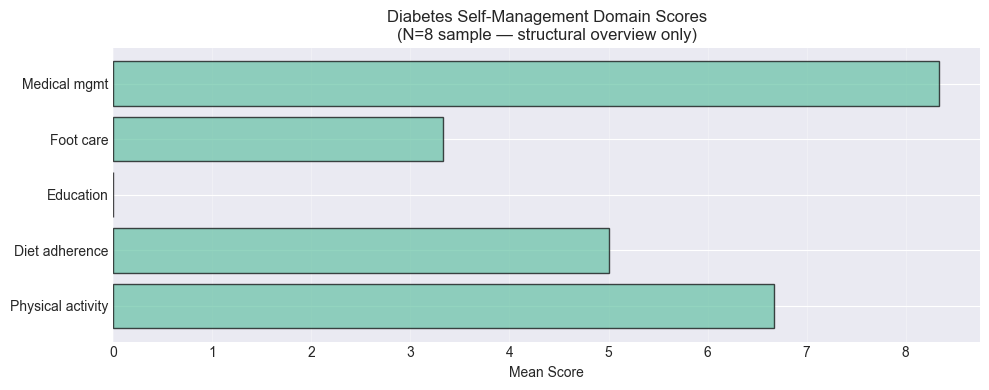

In [8]:
# Domain summary bar chart
if n_dml > 0:
    domain_means = {}
    for domain, keys in dml_domains.items():
        present = [k for k in keys if k in dml_wide.columns]
        if present:
            domain_means[domain] = dml_wide[present].mean(axis=1).mean()

    if domain_means:
        fig, ax = plt.subplots(figsize=(10, 4))
        domains = list(domain_means.keys())
        means   = list(domain_means.values())
        ax.barh(domains, means, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Mean Score')
        ax.set_title('Diabetes Self-Management Domain Scores\n(N=8 sample — structural overview only)')
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 6. Medical History & Family History

**Medical history** (`mhoccur_*`): Binary (0/1) self-reported comorbidities — cardiovascular, ophthalmic, neurological, musculoskeletal, metabolic, and other conditions.  
**Family history** (`fh_dm2pt`, `fh_dm2sb`): Family history of Type 2 diabetes in parents and siblings.

In [9]:
# Medical history
mh_long = obs_df[
    obs_df['item_key'].str.startswith('mhoccur')
][['person_id', 'item_key', 'value_as_number']].copy()

n_mh = mh_long['person_id'].nunique()
print(f'Medical history — patients with data: {n_mh}')
print(f'Unique comorbidity items: {mh_long["item_key"].nunique()}')

if n_mh > 0:
    mh_wide = mh_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )
    # Prevalence (fraction of patients reporting each condition)
    prevalence = mh_wide.mean().sort_values(ascending=False)

    # Friendly labels for known codes
    condition_labels = {
        'mhoccur_hbp'  : 'Hypertension',
        'mhoccur_obs'  : 'Obesity',
        'mhoccur_crt'  : 'Cataracts',
        'mhoccur_ded'  : 'Dry eye disease',
        'mhoccur_glc'  : 'Glaucoma',
        'mhoccur_amd'  : 'Age-related macular degen.',
        'mhoccur_pdr'  : 'Diabetic retinopathy',
        'mhoccur_rvo'  : 'Retinal vascular occlusion',
        'mhoccur_mi'   : 'Myocardial infarction',
        'mhoccur_strk' : 'Stroke',
        'mhoccur_cvdot': 'Other CVD',
        'mhoccur_ca'   : 'Cancer',
        'mhoccur_oa'   : 'Osteoarthritis',
        'mhoccur_ra'   : 'Rheumatoid arthritis',
        'mhoccur_pd'   : 'Parkinson disease',
        'mhoccur_ad'   : 'Alzheimer disease',
        'mhoccur_cogn' : 'Cognitive impairment',
        'mhoccur_lbp'  : 'Low back pain',
        'mhoccur_rnl'  : 'Renal disease',
        'mhoccur_gi'   : 'GI disorder',
        'mhoccur_ms'   : 'Multiple sclerosis',
        'mhoccur_cns'  : 'Other CNS disorder',
        'mhoccur_clsh' : 'Cholesterol/lipid disorder',
        'mhoccur_plm'  : 'Pulmonary disease',
        'mhoccur_circ' : 'Circulatory disorder',
        'mhoccur_ear'  : 'Hearing impairment',
        'mhoccur_ua'   : 'Urinary/bladder disorder',
    }

    labeled_prev = prevalence.rename(lambda x: condition_labels.get(x, x))

    print(f'\nComorbidity prevalence (this sample, N={n_mh}):')
    print(labeled_prev.to_string())

Medical history — patients with data: 4
Unique comorbidity items: 30

Comorbidity prevalence (this sample, N=4):
item_key
mhoccur_fallot                1.000000
Cataracts                     0.750000
Hypertension                  0.500000
Urinary/bladder disorder      0.500000
Rheumatoid arthritis          0.500000
Cholesterol/lipid disorder    0.500000
Obesity                       0.500000
GI disorder                   0.500000
Dry eye disease               0.500000
mhoccur_fall                  0.333333
mhoccur_yn                    0.333333
Hearing impairment            0.250000
Osteoarthritis                0.250000
Circulatory disorder          0.250000
Pulmonary disease             0.250000
Other CVD                     0.250000
Other CNS disorder            0.250000
Glaucoma                      0.250000
Myocardial infarction         0.000000
Multiple sclerosis            0.000000
Low back pain                 0.000000
Age-related macular degen.    0.000000
Parkinson disease   

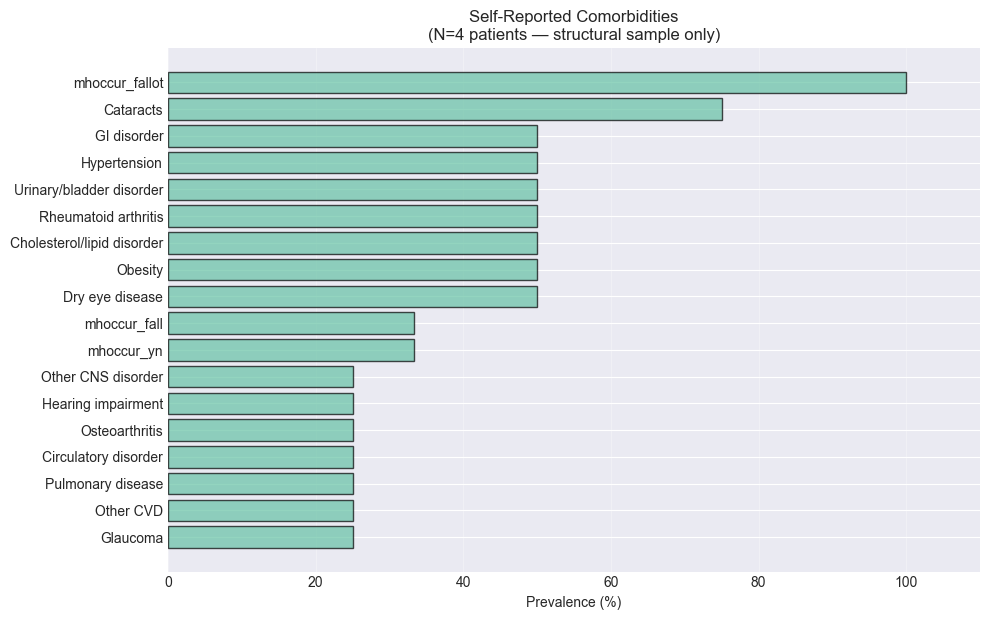


Family history — patients with data: 3
  T2D in parent(s): 1/3 positive
  T2D in sibling(s): 556/3 positive


In [10]:
if n_mh > 0 and len(labeled_prev) > 0:
    # Only plot conditions with non-zero prevalence
    nonzero = labeled_prev[labeled_prev > 0].sort_values()

    if len(nonzero) > 0:
        fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero) * 0.35)))
        ax.barh(nonzero.index, nonzero.values * 100, edgecolor='black', alpha=0.7)
        ax.set_xlabel('Prevalence (%)')
        ax.set_title(f'Self-Reported Comorbidities\n(N={n_mh} patients — structural sample only)')
        ax.set_xlim(0, 110)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print('All comorbidity values are 0 in this sample.')

# Family history
fh_keys = ['fh_dm2pt', 'fh_dm2sb']
fh_long = obs_df[
    obs_df['item_key'].isin(fh_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_fh = fh_long['person_id'].nunique()
print(f'\nFamily history — patients with data: {n_fh}')
if n_fh > 0:
    fh_wide = fh_long.pivot_table(index='person_id', columns='item_key', values='value_as_number')
    for col in fh_keys:
        if col in fh_wide.columns:
            label = 'T2D in parent(s)' if col == 'fh_dm2pt' else 'T2D in sibling(s)'
            pos = fh_wide[col].sum()
            total = fh_wide[col].notna().sum()
            print(f'  {label}: {int(pos)}/{int(total)} positive')

## 7. Survey Completeness Summary

A scorecard of all survey instruments present in the observation sample.

In [11]:
n_total_patients = obs_df['person_id'].nunique()

instruments = {
    'CES-D-10 (depression)':          [f'ces{i}' for i in range(1, 11)] + ['cestl'],
    'PAID-5 (diabetes distress)':     ['paid_scrd', 'paid_dpr', 'paid_wr', 'paid_eng', 'paid_cml', 'paidscore'],
    'Diet survey':                    [f'diet{i}' for i in range(1, 10)] + ['dietscore'],
    'Diabetes self-management':       ['dmlact', 'dmlvex', 'dmlhex', 'dmlsugar', 'dmlgrain',
                                        'dmlpor', 'dmlfrveg', 'dmledu', 'dmlfeet', 'dmlmd'],
    'Medical history (comorbidities)':obs_df[obs_df['item_key'].str.startswith('mhoccur')]['item_key'].unique().tolist(),
    'Family history of T2D':          ['fh_dm2pt', 'fh_dm2sb'],
    'Visual impairment (self-report)': [f'via{i}' for i in range(1, 7)],
    'Substance use':                  ['sualcage', 'sualcdrv', 'subrdosfr', 'sulqdosfr', 'suvptoyr'],
    'OTC medications':                ['cm_act', 'cm_ant', 'cm_asp', 'cm_dcg', 'cm_ibp', 'cm_slp'],
    'PhenX SDOH (item-level)':        [f'pxrd{i}' for i in range(1, 55)],
}

rows = []
for name, keys in instruments.items():
    in_sample = obs_df[obs_df['item_key'].isin(keys)]['person_id'].nunique()
    rows.append({
        'Instrument': name,
        '# Items': len(keys),
        'Patients with data': in_sample,
        'Completeness (%)': f'{in_sample / n_total_patients * 100:.0f}%',
        'In sample?': 'Yes' if in_sample > 0 else 'NO — not in sample',
    })

completeness_df = pd.DataFrame(rows)
display(completeness_df)

missing = completeness_df[completeness_df['In sample?'].str.startswith('NO')]
if len(missing) > 0:
    print('\n⚠️  Instruments NOT represented in this 1000-row sample:')
    for _, row in missing.iterrows():
        print(f'  - {row["Instrument"]}')
    print('\n  These exist in the full observation.csv but were not included in the sample.')
    print('  Recommend: download a targeted observation sample for these instruments before ML feature engineering.')

,Instrument,# Items,Patients with data,Completeness (%),In sample?
0,CES-D-10 (depression),11,6,75%,Yes
1,PAID-5 (diabetes distress),6,4,50%,Yes
2,Diet survey,10,2,25%,Yes
3,Diabetes self-management,10,3,38%,Yes
4,Medical history (comorbidities),30,4,50%,Yes
5,Family history of T2D,2,3,38%,Yes
6,Visual impairment (self-report),6,3,38%,Yes
7,Substance use,5,3,38%,Yes
8,OTC medications,6,3,38%,Yes
9,PhenX SDOH (item-level),54,3,38%,Yes


## 8. Clinical Measurements — Vitals

The measurement table (OMOP long format) contains vitals, labs, and ophthalmology assessments.  
We parse the same way as the observation table and pivot to wide format.

In [12]:
# Parse measurement item key
meas_df['item_key'] = (
    meas_df['measurement_source_value']
    .str.strip('"')
    .str.split(',', n=1)
    .str[0]
    .str.strip()
)

print('Measurement table overview:')
print(f'  Total rows          : {len(meas_df)}')
print(f'  Unique patients     : {meas_df["person_id"].nunique()}')
print(f'  Unique item keys    : {meas_df["item_key"].nunique()}')
print(f'\nAll unique item keys:')
for k in sorted(meas_df['item_key'].unique()):
    n = (meas_df['item_key'] == k).sum()
    print(f'  {k:<35} ({n} rows)')

Measurement table overview:
  Total rows          : 1000
  Unique patients     : 21
  Unique item keys    : 49

All unique item keys:
  bmi_vsorres                         (20 rows)
  bp1_diabp_vsorres                   (20 rows)
  bp1_sysbp_vsorres                   (20 rows)
  bp2_diabp_vsorres                   (20 rows)
  bp2_sysbp_vsorres                   (20 rows)
  height_vsorres                      (21 rows)
  hip_vsorres                         (21 rows)
  lbscat_a1c                          (21 rows)
  lbscat_hct                          (21 rows)
  lbscat_mch                          (21 rows)
  lbscat_mchc                         (21 rows)
  lbscat_mcv                          (21 rows)
  lbscat_plt                          (21 rows)
  lbscat_rbc                          (21 rows)
  lbscat_rdw                          (21 rows)
  lbscat_wbc                          (21 rows)
  mlcsodfcl                           (21 rows)
  mlcsodlog                           (21 rows)
  

In [13]:
vitals_keys = [
    'bmi_vsorres', 'height_vsorres', 'weight_vsorres',
    'waist_vsorres', 'hip_vsorres', 'whr_vsorres',
    'bp1_sysbp_vsorres', 'bp1_diabp_vsorres',
    'bp2_sysbp_vsorres', 'bp2_diabp_vsorres',
    'pulse_vsorres', 'pulse_vsorres_2',
]

vitals_long = meas_df[
    meas_df['item_key'].isin(vitals_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_vitals = vitals_long['person_id'].nunique()
print(f'Patients with vitals data: {n_vitals}')

if n_vitals > 0:
    vitals_wide = vitals_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )

    # Friendly column renames for display
    rename_map = {
        'bmi_vsorres'        : 'BMI',
        'height_vsorres'     : 'Height_cm',
        'weight_vsorres'     : 'Weight_kg',
        'waist_vsorres'      : 'Waist_cm',
        'hip_vsorres'        : 'Hip_cm',
        'whr_vsorres'        : 'WHR',
        'bp1_sysbp_vsorres'  : 'SBP1',
        'bp1_diabp_vsorres'  : 'DBP1',
        'bp2_sysbp_vsorres'  : 'SBP2',
        'bp2_diabp_vsorres'  : 'DBP2',
        'pulse_vsorres'      : 'Pulse1',
        'pulse_vsorres_2'    : 'Pulse2',
    }
    vitals_display = vitals_wide.rename(columns=rename_map)

    print('\nVitals descriptive statistics:')
    display(vitals_display.describe().round(1))

    # BP stage classification
    if 'SBP1' in vitals_display.columns and 'DBP1' in vitals_display.columns:
        sbp = vitals_display['SBP1'].dropna()
        dbp = vitals_display['DBP1'].dropna()
        common_idx = sbp.index.intersection(dbp.index)
        sbp, dbp = sbp[common_idx], dbp[common_idx]

        def bp_stage(s, d):
            if s < 120 and d < 80:  return 'Normal'
            elif s < 130 and d < 80: return 'Elevated'
            elif s < 140 or d < 90:  return 'Stage 1 HTN'
            else:                    return 'Stage 2 HTN'

        stages = [bp_stage(s, d) for s, d in zip(sbp, dbp)]
        print('\nBlood pressure staging (reading 1):')
        for stage, count in pd.Series(stages).value_counts().items():
            print(f'  {stage:<15}: {count} patients')

Patients with vitals data: 21

Vitals descriptive statistics:


item_key,BMI,DBP1,SBP1,DBP2,SBP2,Height_cm,Hip_cm,Pulse1,Pulse2,Waist_cm,Weight_kg,WHR
count,20.0,20.0,20.0,20.0,20.0,21.0,21.0,20.0,20.0,21.0,20.0,20.0
mean,37.8,77.6,137.9,77.2,135.8,163.2,126.6,74.0,73.4,108.3,102.8,0.9
std,13.7,9.8,15.7,10.1,15.5,8.9,28.7,9.8,9.2,23.9,43.3,0.1
min,18.0,61.0,111.0,54.0,103.0,148.0,83.0,55.0,51.0,77.0,39.4,0.7
25%,25.4,71.5,129.2,71.2,128.5,157.0,100.6,67.2,66.8,85.6,68.4,0.8
50%,35.8,77.0,139.0,77.5,134.0,162.5,124.6,75.0,73.5,106.9,100.8,0.9
75%,47.3,88.2,148.5,85.5,145.8,169.8,151.0,78.5,81.5,122.4,131.3,0.9
max,64.0,93.0,172.0,94.0,169.0,183.6,186.5,91.0,87.0,152.5,215.8,1.0



Blood pressure staging (reading 1):
  Stage 1 HTN    : 12 patients
  Normal         : 4 patients
  Stage 2 HTN    : 3 patients
  Elevated       : 1 patients


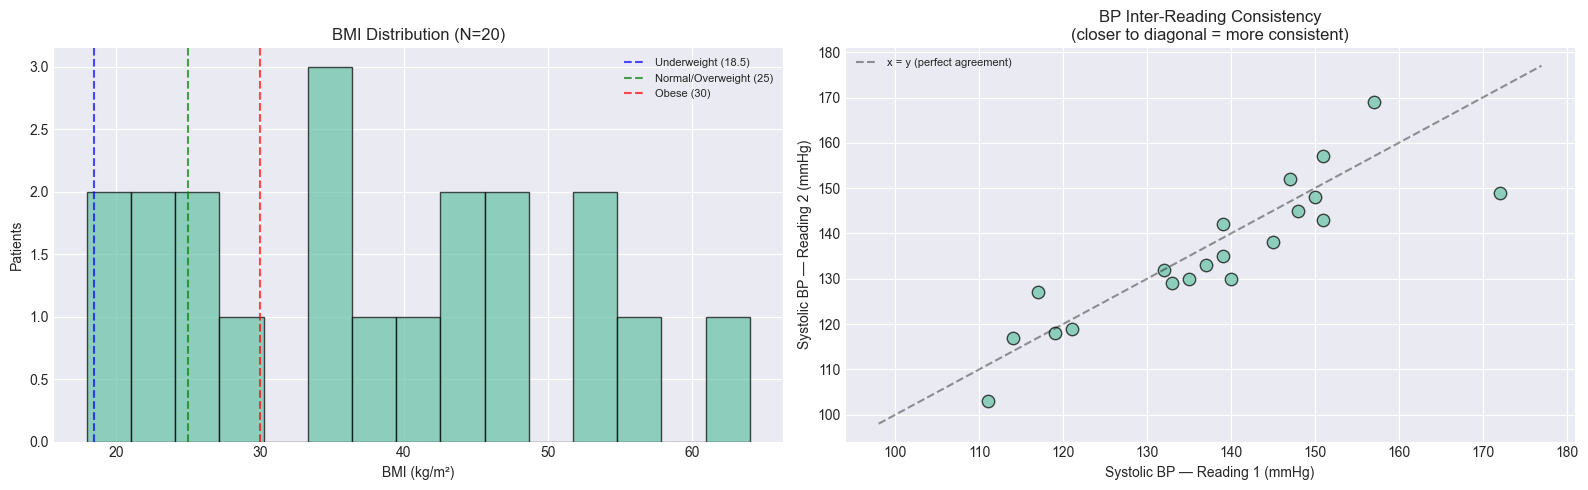

In [14]:
if n_vitals > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # BMI distribution
    if 'BMI' in vitals_display.columns:
        bmi = vitals_display['BMI'].dropna()
        axes[0].hist(bmi, bins=15, edgecolor='black', alpha=0.7)
        for cutoff, label, color in [(18.5, 'Underweight', 'blue'),
                                      (25,   'Normal/Overweight', 'green'),
                                      (30,   'Obese', 'red')]:
            axes[0].axvline(cutoff, linestyle='--', color=color, alpha=0.7, label=f'{label} ({cutoff})')
        axes[0].set_xlabel('BMI (kg/m²)')
        axes[0].set_ylabel('Patients')
        axes[0].set_title(f'BMI Distribution (N={len(bmi)})')
        axes[0].legend(fontsize=8)

    # BP reading 1 vs reading 2 (inter-reading consistency)
    if all(c in vitals_display.columns for c in ['SBP1', 'SBP2']):
        sbp1 = vitals_display['SBP1'].dropna()
        sbp2 = vitals_display['SBP2'].dropna()
        common = sbp1.index.intersection(sbp2.index)
        if len(common) > 1:
            axes[1].scatter(sbp1[common], sbp2[common], edgecolor='black', alpha=0.7, s=80)
            lim_min = min(sbp1[common].min(), sbp2[common].min()) - 5
            lim_max = max(sbp1[common].max(), sbp2[common].max()) + 5
            axes[1].plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='x = y (perfect agreement)')
            axes[1].set_xlabel('Systolic BP — Reading 1 (mmHg)')
            axes[1].set_ylabel('Systolic BP — Reading 2 (mmHg)')
            axes[1].set_title('BP Inter-Reading Consistency\n(closer to diagonal = more consistent)')
            axes[1].legend(fontsize=8)
        else:
            axes[1].text(0.5, 0.5, 'Insufficient paired BP readings', ha='center', va='center')
            axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## 9. Clinical Measurements — Lab Values

Lab values include a CBC panel and a field labeled `lbscat_a1c`.

> **⚠️ HbA1c Label Issue**: The `lbscat_a1c` field is labeled `"Hemoglobin - g/dL"` in the source data, and values range ~11–14 g/dL — consistent with hemoglobin concentration, **not** HbA1c percentage (which would be 5–12%).  
> True HbA1c (glycated hemoglobin, %) may be stored under a different concept ID or source value in the full dataset. **Do not use `lbscat_a1c` as HbA1c in ML features without verification.**

In [15]:
lab_keys = [
    'lbscat_a1c',   # Labeled 'Hemoglobin - g/dL' — NOT HbA1c %
    'lbscat_wbc', 'lbscat_rbc', 'lbscat_hct',
    'lbscat_mcv', 'lbscat_mch', 'lbscat_mchc',
    'lbscat_rdw', 'lbscat_plt',
]

lab_long = meas_df[
    meas_df['item_key'].isin(lab_keys)
][['person_id', 'item_key', 'value_as_number']].copy()

n_labs = lab_long['person_id'].nunique()
print(f'Patients with lab data: {n_labs}')

if n_labs > 0:
    lab_wide = lab_long.pivot_table(
        index='person_id', columns='item_key', values='value_as_number'
    )

    # Clinical reference ranges
    ref_ranges = {
        'lbscat_a1c'  : (12.0, 17.5, 'Hemoglobin g/dL (NOT HbA1c %)'),
        'lbscat_wbc'  : (4.5,  11.0,  'WBC ×10³/µL'),
        'lbscat_rbc'  : (4.0,  5.5,   'RBC ×10⁶/µL'),
        'lbscat_hct'  : (36,   50,    'Hematocrit %'),
        'lbscat_mcv'  : (80,   100,   'MCV fL'),
        'lbscat_mch'  : (27,   33,    'MCH pg'),
        'lbscat_mchc' : (32,   36,    'MCHC g/dL'),
        'lbscat_rdw'  : (11.5, 14.5,  'RDW %'),
        'lbscat_plt'  : (150,  400,   'Platelets ×10³/µL'),
    }

    print('\nLab values — descriptive statistics:')
    stats_rows = []
    for key in lab_keys:
        if key in lab_wide.columns:
            col = lab_wide[key].dropna()
            low, high, label = ref_ranges.get(key, (None, None, key))
            n_oob = ((col < low) | (col > high)).sum() if (low and high) else 0
            stats_rows.append({
                'Field': key,
                'Label': label,
                'N': len(col),
                'Mean': round(col.mean(), 2),
                'Std': round(col.std(), 2),
                'Min': round(col.min(), 2),
                'Max': round(col.max(), 2),
                'Ref range': f'{low}–{high}' if low else 'N/A',
                'Out of range': n_oob,
            })
    display(pd.DataFrame(stats_rows))

    print('\n⚠️  lbscat_a1c values range ~11–14 — this is hemoglobin g/dL, NOT HbA1c %.')
    print('   Investigate measurement_concept_id for the true HbA1c field before using in models.')

Patients with lab data: 21

Lab values — descriptive statistics:


,Field,Label,N,Mean,Std,Min,Max,Ref range,Out of range
0,lbscat_a1c,Hemoglobin g/dL (NOT HbA1c %),21,13.00,1.05,11.40,14.8,12.0–17.5,5
1,lbscat_wbc,WBC ×10³/µL,21,6.28,1.54,4.00,10.1,4.5–11.0,2
2,lbscat_rbc,RBC ×10⁶/µL,21,4.66,0.65,3.66,5.8,4.0–5.5,6
3,lbscat_hct,Hematocrit %,21,40.52,3.65,33.90,47.3,36–50,1
4,lbscat_mcv,MCV fL,21,87.76,6.40,74.00,97.0,80–100,3
5,lbscat_mch,MCH pg,21,28.20,2.92,22.10,31.8,27–33,6
6,lbscat_mchc,MCHC g/dL,21,32.12,1.23,29.30,33.8,32–36,10
7,lbscat_rdw,RDW %,21,13.77,1.42,11.60,17.1,11.5–14.5,5
8,lbscat_plt,Platelets ×10³/µL,21,266.95,69.23,143.00,461.0,150–400,2



⚠️  lbscat_a1c values range ~11–14 — this is hemoglobin g/dL, NOT HbA1c %.
   Investigate measurement_concept_id for the true HbA1c field before using in models.


## 10. EDA Verification — Sleep Data Anomaly

**NB02 showed** `average_sleep_hours` values of 0.27–0.43 hours, which appeared implausible for nightly sleep.  
**Hypothesis**: The Garmin device records multiple sleep segments per night (sleep cycles, naps). `average_sleep_hours` is the **mean per-segment duration** (≈18 min = 0.3 hrs), **not the total nightly sleep**.  
We test this using the full activity manifest (2,184 participants).

In [16]:
sleep_cols = ['person_id', 'average_sleep_hours', 'sleep_record_count', 'sensor_sampling_duration_days']
sleep = activity[sleep_cols].dropna(subset=['average_sleep_hours']).copy()

print('Sleep data from full activity manifest (2,184 participants):')
print(f'  Participants with sleep data : {len(sleep)}')
print(f'  average_sleep_hours — mean   : {sleep["average_sleep_hours"].mean():.3f} hrs ({sleep["average_sleep_hours"].mean()*60:.0f} min)')
print(f'  average_sleep_hours — median : {sleep["average_sleep_hours"].median():.3f} hrs')
print(f'  average_sleep_hours — range  : [{sleep["average_sleep_hours"].min():.3f}, {sleep["average_sleep_hours"].max():.3f}]')
print(f'\n  sleep_record_count — median  : {sleep["sleep_record_count"].median():.0f} records per participant')
print(f'  sensor_duration    — median  : {sleep["sensor_sampling_duration_days"].median():.0f} days')

# Calculate estimated nightly sleep total
sleep['est_nightly_sleep_hrs'] = (
    sleep['average_sleep_hours'] * sleep['sleep_record_count']
    / sleep['sensor_sampling_duration_days']
)

print(f'\nEstimated nightly sleep (avg_hrs × record_count / days):')
print(f'  Mean   : {sleep["est_nightly_sleep_hrs"].mean():.2f} hrs')
print(f'  Median : {sleep["est_nightly_sleep_hrs"].median():.2f} hrs')
print(f'  Range  : [{sleep["est_nightly_sleep_hrs"].min():.2f}, {sleep["est_nightly_sleep_hrs"].max():.2f}]')

plausible = ((sleep['est_nightly_sleep_hrs'] >= 4) & (sleep['est_nightly_sleep_hrs'] <= 12)).mean() * 100
print(f'  Plausible (4–12 hrs): {plausible:.1f}% of participants')

Sleep data from full activity manifest (2,184 participants):
  Participants with sleep data : 2184
  average_sleep_hours — mean   : 0.390 hrs (23 min)
  average_sleep_hours — median : 0.390 hrs
  average_sleep_hours — range  : [0.000, 1.410]

  sleep_record_count — median  : 247 records per participant
  sensor_duration    — median  : 15 days

Estimated nightly sleep (avg_hrs × record_count / days):
  Mean   : inf hrs
  Median : 6.72 hrs
  Range  : [0.00, inf]
  Plausible (4–12 hrs): 79.7% of participants


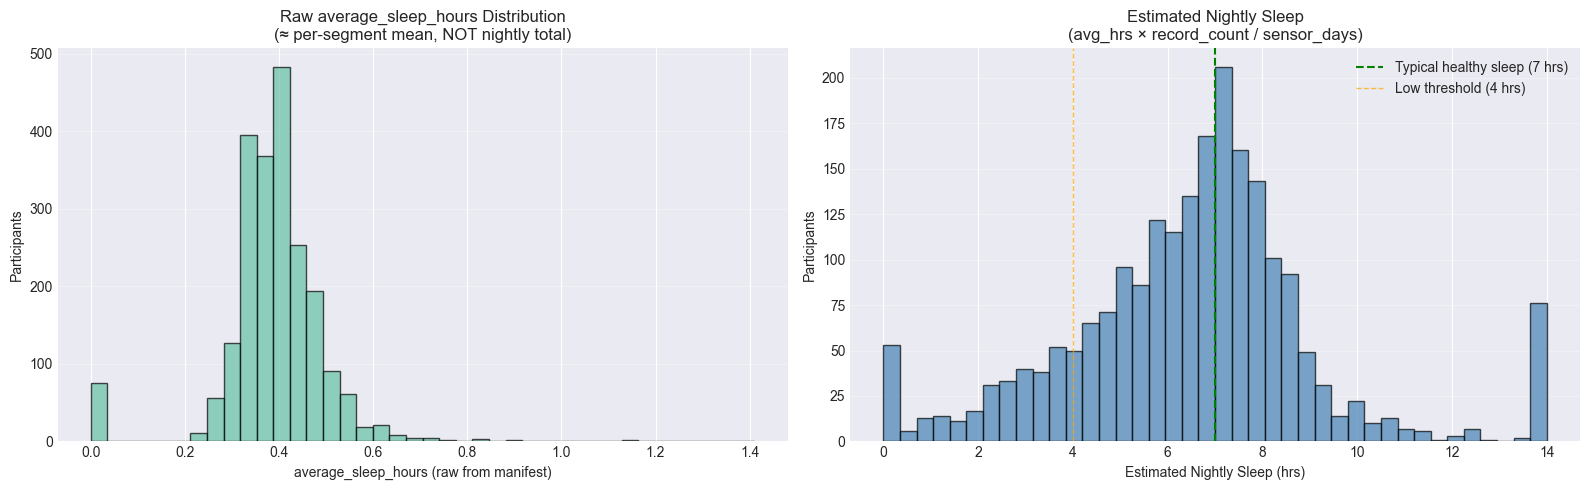


--- FINDING ---
average_sleep_hours median = 0.39 hrs (23 min per segment)
Estimated nightly sleep median = 6.72 hrs

INTERPRETATION: average_sleep_hours is the mean per-segment sleep duration from Garmin,
not nightly total sleep. For ML features, use:
  est_nightly_sleep_hrs = average_sleep_hours × sleep_record_count / sensor_sampling_duration_days

The NB02 EDA was incorrect to treat average_sleep_hours as nightly sleep duration.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw average_sleep_hours
axes[0].hist(sleep['average_sleep_hours'], bins=40, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('average_sleep_hours (raw from manifest)')
axes[0].set_ylabel('Participants')
axes[0].set_title('Raw average_sleep_hours Distribution\n(≈ per-segment mean, NOT nightly total)')
axes[0].grid(axis='y', alpha=0.3)

# Estimated nightly sleep
est_clipped = sleep['est_nightly_sleep_hrs'].clip(upper=14)
axes[1].hist(est_clipped, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(7, color='green', linestyle='--', linewidth=1.5, label='Typical healthy sleep (7 hrs)')
axes[1].axvline(4, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Low threshold (4 hrs)')
axes[1].set_xlabel('Estimated Nightly Sleep (hrs)')
axes[1].set_ylabel('Participants')
axes[1].set_title('Estimated Nightly Sleep\n(avg_hrs × record_count / sensor_days)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n--- FINDING ---')
print(f'average_sleep_hours median = {sleep["average_sleep_hours"].median():.2f} hrs ({sleep["average_sleep_hours"].median()*60:.0f} min per segment)')
print(f'Estimated nightly sleep median = {sleep["est_nightly_sleep_hrs"].median():.2f} hrs')
print()
print('INTERPRETATION: average_sleep_hours is the mean per-segment sleep duration from Garmin,')
print('not nightly total sleep. For ML features, use:')
print('  est_nightly_sleep_hrs = average_sleep_hours × sleep_record_count / sensor_sampling_duration_days')
print()
print('The NB02 EDA was incorrect to treat average_sleep_hours as nightly sleep duration.')

## 11. EDA Verification — Clustering, QTc & Site Imbalance

Three specific findings from NB02 that warrant scrutiny.

In [18]:
# --- 11a. Clustering instability ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'mean_glucose', 'cv_glucose', 'tir', 'tar', 'tbr',
    'Rate', 'QTc', 'average_daily_activity',
    'average_sleep_hours', 'average_stress_level',
]
available = [f for f in cluster_features if f in eda_df.columns]
X = eda_df[available].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'NB02 clustering — facts:')
print(f'  N (complete cases) : {len(X)}')
print(f'  Features used      : {len(available)}')
print(f'  Feature-to-sample ratio: {len(available)}/{len(X)} = {len(available)/len(X):.2f}')
print(f'  (Ratio > 0.1 is concerning for clustering stability)')

print(f'\nK-Means (k=4) cluster sizes across 10 random seeds:')
print(f'  {"Seed":<6} | Cluster sizes')
print(f'  -------+' + '-'*30)
for seed in range(10):
    km = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = km.fit_predict(X_scaled)
    sizes = sorted(pd.Series(labels).value_counts().values, reverse=True)
    singleton_flag = ' ← singletons' if min(sizes) == 1 else ''
    print(f'  {seed:<6} | {sizes}{singleton_flag}')

print()
print('CONCLUSION: Clustering results from NB02 are unstable and should NOT be cited.')
print('Defer unsupervised clustering to when the full dataset (N≥500) is available.')

NB02 clustering — facts:
  N (complete cases) : 25
  Features used      : 10
  Feature-to-sample ratio: 10/25 = 0.40
  (Ratio > 0.1 is concerning for clustering stability)

K-Means (k=4) cluster sizes across 10 random seeds:
  Seed   | Cluster sizes
  -------+------------------------------
  0      | [np.int64(12), np.int64(9), np.int64(3), np.int64(1)] ← singletons
  1      | [np.int64(17), np.int64(6), np.int64(1), np.int64(1)] ← singletons
  2      | [np.int64(12), np.int64(9), np.int64(3), np.int64(1)] ← singletons
  3      | [np.int64(17), np.int64(6), np.int64(1), np.int64(1)] ← singletons
  4      | [np.int64(12), np.int64(11), np.int64(1), np.int64(1)] ← singletons
  5      | [np.int64(12), np.int64(11), np.int64(1), np.int64(1)] ← singletons
  6      | [np.int64(12), np.int64(11), np.int64(1), np.int64(1)] ← singletons
  7      | [np.int64(12), np.int64(11), np.int64(1), np.int64(1)] ← singletons
  8      | [np.int64(12), np.int64(6), np.int64(6), np.int64(1)] ← singletons
  9

In [19]:
# --- 11b. QTc prolongation by study group ---
print('QTc Prolongation (>450 ms) — exact counts by study group:')
print('='*70)

for group in sorted(eda_df['study_group'].unique()):
    g = eda_df[eda_df['study_group'] == group]
    qtc_valid = g['QTc'].dropna()
    n_total = len(qtc_valid)
    n_prolonged = (qtc_valid > 450).sum()
    pct = n_prolonged / n_total * 100 if n_total > 0 else 0
    print(f'  {group[:55]:<55} : {n_prolonged}/{n_total} = {pct:.1f}%')

print()
print('NOTE: "healthy" group shows ~13% prolonged QTc because N=15 ECG records.')
print('A single outlier patient = 6.7%; two = 13.3%. This is a small-sample artifact,')
print('not a clinical finding. Do not report in any context as a population estimate.')

QTc Prolongation (>450 ms) — exact counts by study group:
  healthy                                                 : 2/8 = 25.0%
  insulin_dependent                                       : 0/3 = 0.0%
  oral_medication_and_or_non_insulin_injectable_medicatio : 0/3 = 0.0%
  pre_diabetes_lifestyle_controlled                       : 1/11 = 9.1%

NOTE: "healthy" group shows ~13% prolonged QTc because N=15 ECG records.
A single outlier patient = 6.7%; two = 13.3%. This is a small-sample artifact,
not a clinical finding. Do not report in any context as a population estimate.


In [20]:
# --- 11c. Site imbalance check ---
print('Clinical site distribution in EDA sample:')
print(eda_df['clinical_site'].value_counts())

print('\nStudy group × site cross-tab:')
display(pd.crosstab(eda_df['clinical_site'], eda_df['study_group']))

site_stats = eda_df.groupby('clinical_site')[['mean_glucose', 'tir', 'age']].agg(['mean', 'std', 'count'])
print('\nKey metrics by site:')
display(site_stats.round(1))

Clinical site distribution in EDA sample:
clinical_site
UW      36
UCSD     8
UAB      8
Name: count, dtype: int64

Study group × site cross-tab:


study_group,healthy,insulin_dependent,oral_medication_and_or_non_insulin_injectable_medication_controlled,pre_diabetes_lifestyle_controlled
clinical_site,,,,
UAB,1,4,2,1
UCSD,3,0,2,3
UW,11,6,6,13



Key metrics by site:


mean_glucose               tir               age            
                      mean   std count  mean   std count  mean   std count
clinical_site                                                             
UAB                  172.3  53.3     8  63.9  34.6     8  61.0  12.6     8
UCSD                 116.7   8.6     8  97.8   2.4     8  64.6   9.4     8
UW                   140.1  42.4    36  86.9  21.5    36  57.2  10.2    36

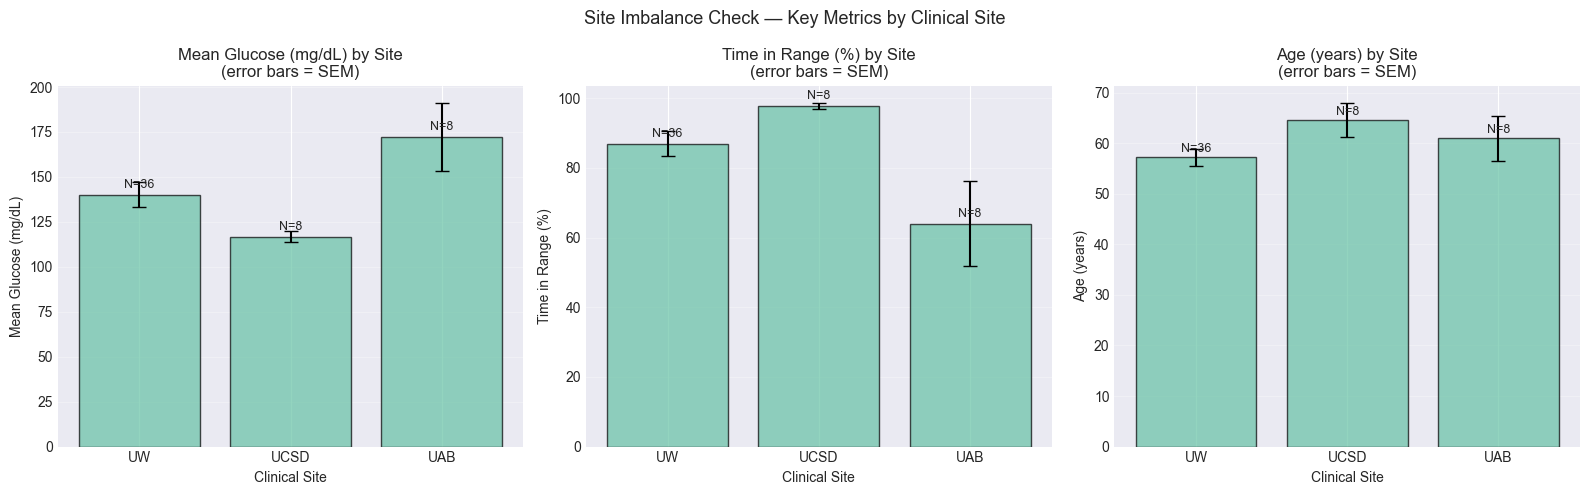


Note: Sample is heavily UW-weighted (36/52). Interpret site differences cautiously.
Full dataset breakdown (from participants.tsv) should be checked before assuming site effects.


In [21]:
sites = eda_df['clinical_site'].unique()
metrics = ['mean_glucose', 'tir', 'age']
metric_labels = ['Mean Glucose (mg/dL)', 'Time in Range (%)', 'Age (years)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    site_data = [eda_df[eda_df['clinical_site'] == s][metric].dropna() for s in sites]
    means = [d.mean() for d in site_data]
    sems  = [d.sem() for d in site_data]
    ns    = [len(d) for d in site_data]

    bars = ax.bar(sites, means, yerr=sems, capsize=5, edgecolor='black', alpha=0.7)
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sems)*0.1,
                f'N={n}', ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Clinical Site')
    ax.set_ylabel(label)
    ax.set_title(f'{label} by Site\n(error bars = SEM)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Site Imbalance Check — Key Metrics by Clinical Site', fontsize=13)
plt.tight_layout()
plt.show()

print('\nNote: Sample is heavily UW-weighted (36/52). Interpret site differences cautiously.')
print('Full dataset breakdown (from participants.tsv) should be checked before assuming site effects.')

## 12. Key Findings & Next Steps

---

### 1. Survey / Questionnaire Data Profile

| Instrument | Status |
|---|---|
| CES-D-10 (depression) | ✓ Present; pivot pattern works |
| PAID-5 (diabetes distress) | ✓ Present; diabetes patients only |
| Diet survey | ✓ Present |
| Diabetes self-management (dml*) | ✓ Present; 5 domains |
| Medical history comorbidities | ✓ Present; 27 conditions |
| Family history of T2D | ✓ Present |
| Visual impairment self-report | ✓ Present |
| Substance use | ⚠️ Not in this 1000-row sample |
| OTC medications | ⚠️ Not in this 1000-row sample |
| PhenX SDOH (item-level, pxrd1-54) | ⚠️ Metadata only; item responses not sampled |

**Action**: Before ML feature engineering, download a targeted observation sample that includes substance use, OTC medications, and PhenX discrimination items.

---

### 2. Clinical Measurements

- **Vitals** (BMI, BP, waist/hip, pulse): Available for ~21 patients. Data structure confirmed. BP inter-reading consistency can be checked.
- **`lbscat_a1c` is NOT HbA1c**: Values of 11–14 indicate this is hemoglobin g/dL (complete blood count), not glycated hemoglobin (%). True HbA1c must be found under a different field or concept ID in the full dataset before it can be used as an ML feature.
- **CBC panel** (WBC, RBC, hematocrit, MCV, MCH, MCHC, RDW, platelets): Present and clean.

---

### 3. EDA Corrections (NB02)

| Issue | Resolution |
|---|---|
| `average_sleep_hours` (0.3 hrs) | Per-segment duration, not nightly total. Use `avg × records / days` instead. |
| K-Means clustering (N=25) | Unstable across random seeds. Two of four clusters were singletons. **Do not cite as a finding.** |
| QTc prolongation in "healthy" group (13.3%) | Artifact of N=15. Two patients = 13.3%. Not a clinical finding. |
| Site imbalance (36 UW / 8 UCSD / 8 UAB) | Confound risk. Check cross-tabulation with study group on full dataset before modeling. |

---

### Next Steps Before Data Cleaning

1. **Download targeted observation samples** for substance use, medications, and PhenX SDOH item-level responses
2. **Identify true HbA1c field** in the measurement table (search by measurement_concept_id or source value containing 'glycat', 'a1c', or 'hba1c')
3. **Fix sleep feature** in the EDA merged dataset using the corrected formula
4. **Scale up EDA to the full cohort** before any ML work — current N=52 is sufficient for structural understanding, not for feature selection or distribution estimates
5. **Check site effects** in the full dataset to determine if site should be included as a covariate or used for stratified splits

---

**Next**: Proceed to `05_data_cleaning.ipynb` once targeted observation samples are downloaded and the HbA1c field is verified.